# Cartesian ray image

A minimal cartesian ray-tracing example using the current batcamp API.

In [14]:
from batread import Dataset
import matplotlib.pyplot as plt
import numpy as np

from batcamp import Octree, OctreeInterpolator, OctreeRayTracer

ds = Dataset.from_file("../sample_data/3d__var_2_n00006003.plt")
print(ds)


tree = Octree.from_ds(ds, tree_coord="xyz")
print(tree)

interp = OctreeInterpolator(tree, ds["Rho [g/cm^3]"])
print(interp)

tracer = OctreeRayTracer(tree)
print(tracer)

Title:     'BATSRUS: 3D Data, 2000/01/30 00:00:00.000'
Zone:      '3D   N=0006003'
Variables: 4
Shape:     (21069, 4)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]'].
Octree(tree_coord=xyz, root_shape=(1, 1, 1), leaf_shape=(32, 32, 32), leaf_cells=18432, runtime_cells=21065, levels=4..5)
OctreeInterpolator(tree_coord=xyz, n_points=21069, n_cells=18432, n_components=1)
OctreeRayTracer(tree_coord=xyz)


In [10]:
coords = np.linspace(-215.0, 215.0, 512)
y, z = np.meshgrid(coords, coords, indexing="xy")
origins = np.stack((np.full_like(y, -400.0), y, z), axis=-1)
directions = np.array([1.0, 0.0, 0.0], dtype=float)

origins.shape, directions.shape


((512, 512, 3), (3,))

In [11]:
segments = tracer.trace(origins, directions)
cell_counts = np.diff(segments.ray_offsets).reshape(y.shape)

int(cell_counts.min()), float(np.median(cell_counts)), int(cell_counts.max())


(16, 28.0, 32)

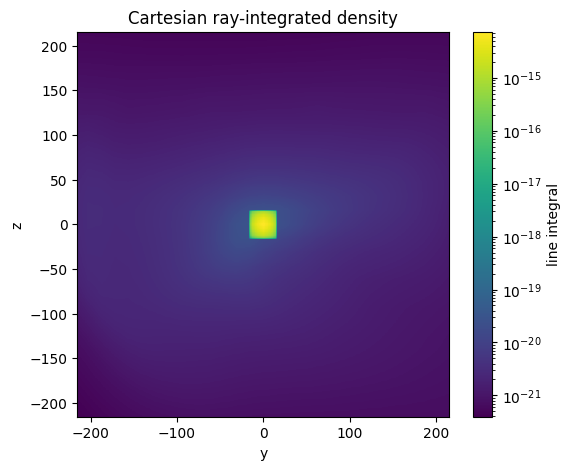

(512, 512)

In [12]:
rho_los, _ = tracer.accumulate_exact_image(interp, origins, directions)

fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.pcolormesh(y, z, rho_los, shading="auto", norm="log")
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_title("Cartesian ray-integrated density")
fig.colorbar(mesh, ax=ax, label="line integral")
plt.show()

rho_los.shape
